# **Concurrent Programming End sem Lab**
## *Submitted By: Atul Dhiman (25901325)*


## **Ques 1 :Replace Negative Values with Zero using CUDA**

In [1]:
import numpy as np
from numba import cuda
import time

In [2]:
@cuda.jit
def replace_negative_with_zero(arr):
    idx = cuda.grid(1)

    if idx < arr.size:
        if arr[idx] < 0:
            arr[idx] = 0


def cpu_version(arr):
    result = arr.copy()
    result[result < 0] = 0
    return result

In [3]:
# Generate Dataset (10 Million Floating-Point Values)
N = 10_000_000
host_array = np.random.uniform(-1000, 1000, N).astype(np.float32)

# CPU Execution
cpu_input = host_array.copy()
start_cpu = time.time()
cpu_result = cpu_version(cpu_input)
end_cpu = time.time()

# GPU Execution
threads_per_block = 256
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

# Transfer data to GPU
gpu_array = cuda.to_device(host_array)

In [4]:
start_gpu = time.time()
replace_negative_with_zero[blocks_per_grid, threads_per_block](gpu_array)

# Copy result back
gpu_result = gpu_array.copy_to_host()
end_gpu = time.time()

# Performance Analysis
cpu_time = end_cpu - start_cpu
gpu_time = end_gpu - start_gpu
speedup = cpu_time / gpu_time

print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)
print("GPU Speedup:", speedup)

# Validation
print("Results Match:", np.allclose(cpu_result, gpu_result))

CPU Time: 0.46602344512939453
GPU Time: 3.457613468170166
GPU Speedup: 0.13478182261246885
Results Match: True


### **Complexity**
- Time Complexity: O(N)
- Space Complexity: O(N)

## **Ques 2: String Frequency Counting using CUDA**

In [5]:
import numpy as np
from numba import cuda
import time

# CUDA Kernel
@cuda.jit

def frequency_count(text_array, freq_array):
    idx = cuda.grid(1)

    if idx < text_array.size:
        char_val = text_array[idx]
        cuda.atomic.add(freq_array, char_val, 1)


# Load Text File
with open("/content/wiki_sample.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [6]:
text = text.lower()
text_bytes = np.array([ord(c) for c in text if ord(c) < 128], dtype=np.int32)

# Frequency array for ASCII characters
freq = np.zeros(128, dtype=np.int32)

# CPU Frequency Counting
start_cpu = time.time()
cpu_freq = np.zeros(128, dtype=np.int32)

for val in text_bytes:
    cpu_freq[val] += 1

end_cpu = time.time()

In [7]:
# GPU Setup
threads_per_block = 256
blocks_per_grid = (text_bytes.size + threads_per_block - 1) // threads_per_block

# Transfer data to GPU
text_gpu = cuda.to_device(text_bytes)
freq_gpu = cuda.to_device(freq)

# GPU Execution
start_gpu = time.time()
frequency_count[blocks_per_grid, threads_per_block](text_gpu, freq_gpu)

# Copy result back
result_gpu = freq_gpu.copy_to_host()
end_gpu = time.time()

# Performance
cpu_time = end_cpu - start_cpu
gpu_time = end_gpu - start_gpu
speedup = cpu_time / gpu_time

print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)
print("GPU Speedup:", speedup)

CPU Time: 0.004073619842529297
GPU Time: 0.05934596061706543
GPU Speedup: 0.06864190587148224


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 24 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [8]:
# Print frequencies
for i in range(97, 123):
    print(chr(i), "->", result_gpu[i])

a -> 401
b -> 60
c -> 155
d -> 195
e -> 583
f -> 107
g -> 111
h -> 224
i -> 355
j -> 20
k -> 32
l -> 201
m -> 128
n -> 378
o -> 346
p -> 54
q -> 4
r -> 350
s -> 359
t -> 324
u -> 63
v -> 46
w -> 66
x -> 6
y -> 75
z -> 0


### **Complexity**
- Time Complexity: O(N)
- Parallel CUDA Execution significantly reduces runtime.

## **Ques3 :Hexagonal Tessellation Pattern using CUDA**

In [9]:
!pip install numba matplotlib numpy pandas

In [10]:
import numpy as np
from numba import cuda
import matplotlib.pyplot as plt
import math
import time

# Canvas size
WIDTH = 2000
HEIGHT = 2000
HEX_SIZE = 30

In [11]:
@cuda.jit
def hex_tessellation(image, hex_size):
    x, y = cuda.grid(2)

    height = image.shape[0]
    width = image.shape[1]

    if x < width and y < height:

        # Hexagon geometry
        q = (2.0 / 3.0 * x) / hex_size
        r = (-1.0 / 3.0 * x + math.sqrt(3)/3.0 * y) / hex_size

        rq = round(q)
        rr = round(r)

        center_x = hex_size * (3.0/2.0 * rq)
        center_y = hex_size * (math.sqrt(3) * (rr + rq/2.0))

        dx = abs(x - center_x)
        dy = abs(y - center_y)

        if dx + dy < hex_size:
          image[y, x] = 255
        else:
          image[y, x] = 0

In [12]:
def cpu_hex_tessellation(width, height, hex_size):
    image = np.zeros((height, width), dtype=np.uint8)

    for y in range(height):
        for x in range(width):
            q = (2.0 / 3.0 * x) / hex_size
            r = (-1.0 / 3.0 * x + math.sqrt(3)/3.0 * y) / hex_size

            rq = round(q)
            rr = round(r)

            center_x = hex_size * (3.0/2.0 * rq)
            center_y = hex_size * (math.sqrt(3) * (rr + rq/2.0))

            dx = abs(x - center_x)
            dy = abs(y - center_y)

            if dx + dy < hex_size:
                image[y, x] = 255

    return image

In [13]:

# CPU Execution
start_cpu = time.time()
cpu_image = cpu_hex_tessellation(WIDTH, HEIGHT, HEX_SIZE)
end_cpu = time.time()

# GPU Setup
threads_per_block = (16, 16)
blocks_x = (WIDTH + threads_per_block[0] - 1) // threads_per_block[0]
blocks_y = (HEIGHT + threads_per_block[1] - 1) // threads_per_block[1]
blocks_per_grid = (blocks_x, blocks_y)

# GPU Image
image_gpu = cuda.device_array((HEIGHT, WIDTH), dtype=np.uint8)

# GPU Execution
start_gpu = time.time()
hex_tessellation[blocks_per_grid, threads_per_block](image_gpu, HEX_SIZE)

result = image_gpu.copy_to_host()
end_gpu = time.time()

CPU Time: 3.722003936767578
GPU Time: 0.12330746650695801
GPU Speedup: 30.18474097476938


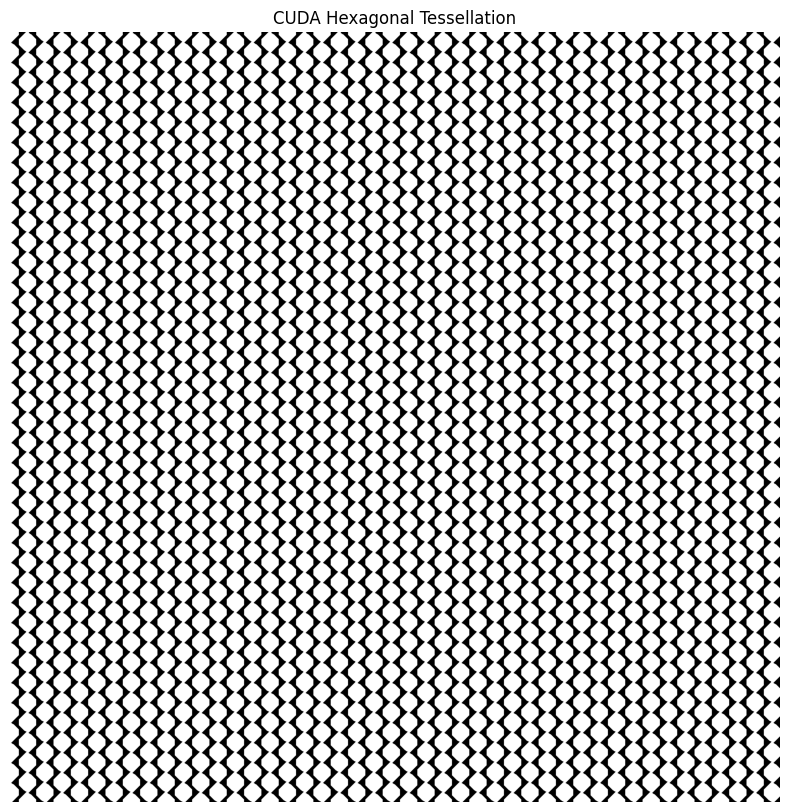

In [14]:
# Performance Analysis
cpu_time = end_cpu - start_cpu
gpu_time = end_gpu - start_gpu
speedup = cpu_time / gpu_time

print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)
print("GPU Speedup:", speedup)

# Display Image
plt.figure(figsize=(10, 10))
plt.imshow(result, cmap='gray')
plt.title("CUDA Hexagonal Tessellation")
plt.axis('off')
plt.show()